# Image Segmentation with Vision Transformers

## Tutorial: Semantic & Interactive Segmentation using SegFormer and Segment Anything Model (SAM)

In this notebook, we'll explore modern transformer-based approaches to image segmentation:
- **SegFormer**: Efficient semantic segmentation
- **Segment Anything Model (SAM)**: State-of-the-art interactive segmentation

We'll load pretrained models from Hugging Face and demonstrate inference on real images.

In [1]:
# # Install required packages
# import subprocess
# import sys

# packages = [
#     'torch',
#     'torchvision',
#     'transformers',
#     'pillow',
#     'matplotlib',
#     'numpy',
#     'opencv-python'
# ]

# print("Installing required packages...")
# subprocess.check_call([sys.executable, "-m", "pip", "-q", "install"] + packages)
# print("✓ Installation complete!")

In [4]:
# Import libraries
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation
from transformers import pipeline
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.12.1+cu130


## 1. SegFormer: Efficient Semantic Segmentation

**What is SegFormer?**
- Transformer-based semantic segmentation model by NVIDIA
- Efficient alternative to dense prediction networks
- Combines Vision Transformer (ViT) encoder with lightweight decoder
- Fast inference, suitable for real-time applications

**Model**: `nvidia/segformer-b0-finetuned-ade-512-512`
- Trained on ADE20K dataset (150 semantic classes)
- Capable of segmenting indoor and outdoor scenes
- Fast inference on CPU/GPU

In [5]:
# Load SegFormer model
print("Loading SegFormer model...")
model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

image_processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForSemanticSegmentation.from_pretrained(model_name).to(device)
model.eval()

print(f"✓ Model loaded: {model_name}")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M")

Loading SegFormer model...


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

✓ Model loaded: nvidia/segformer-b0-finetuned-ade-512-512
Model parameters: 3.8M


Image shape: (547, 365)
✓ Image loaded


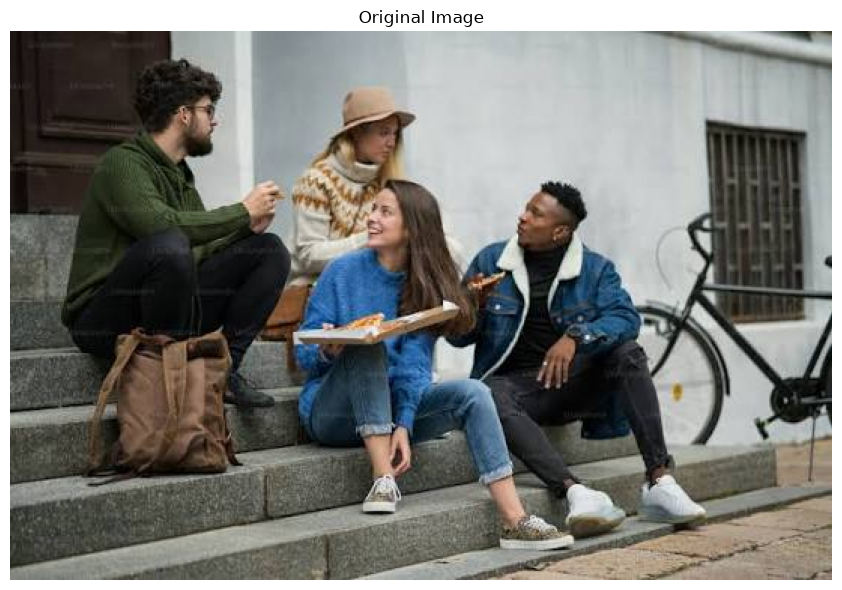

In [10]:
# Download a sample image
# url = "https://static.vecteezy.com/system/resources/thumbnails/074/239/475/small/a-diverse-collection-of-musical-instruments-featuring-guitars-drums-saxophones-a-piano-and-string-instruments-photo.jpg"
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRFRccvYqsdnhzz_0QgD5Fm6jB80AkhCeSFIec3h31Dq9z81xHCUpfMeRI&s=10"

print("Downloading sample image...")
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert('RGB')

print(f"Image shape: {image.size}")
print(f"✓ Image loaded")

# Display original image
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.title("Original Image")
plt.axis('off')
plt.tight_layout()
plt.show()

In [11]:
# Run SegFormer inference
print("Running SegFormer inference...")

with torch.no_grad():
    inputs = image_processor(images=image, return_tensors="pt").to(device)
    outputs = model(**inputs)
    logits = outputs.logits

# Upscale logits to match image size
logits_upsampled = torch.nn.functional.interpolate(
    logits,
    size=image.size[::-1],
    mode="bilinear",
    align_corners=False
)

# Get predicted class for each pixel
pred_seg = logits_upsampled.argmax(dim=1)[0].cpu().numpy()

print(f"✓ Segmentation complete")
print(f"Number of classes detected: {pred_seg.max() + 1}")
print(f"Unique classes: {np.unique(pred_seg)}")

Running SegFormer inference...
✓ Segmentation complete
Number of classes detected: 128
Unique classes: [  0   1   6  11  12  53  59 127]


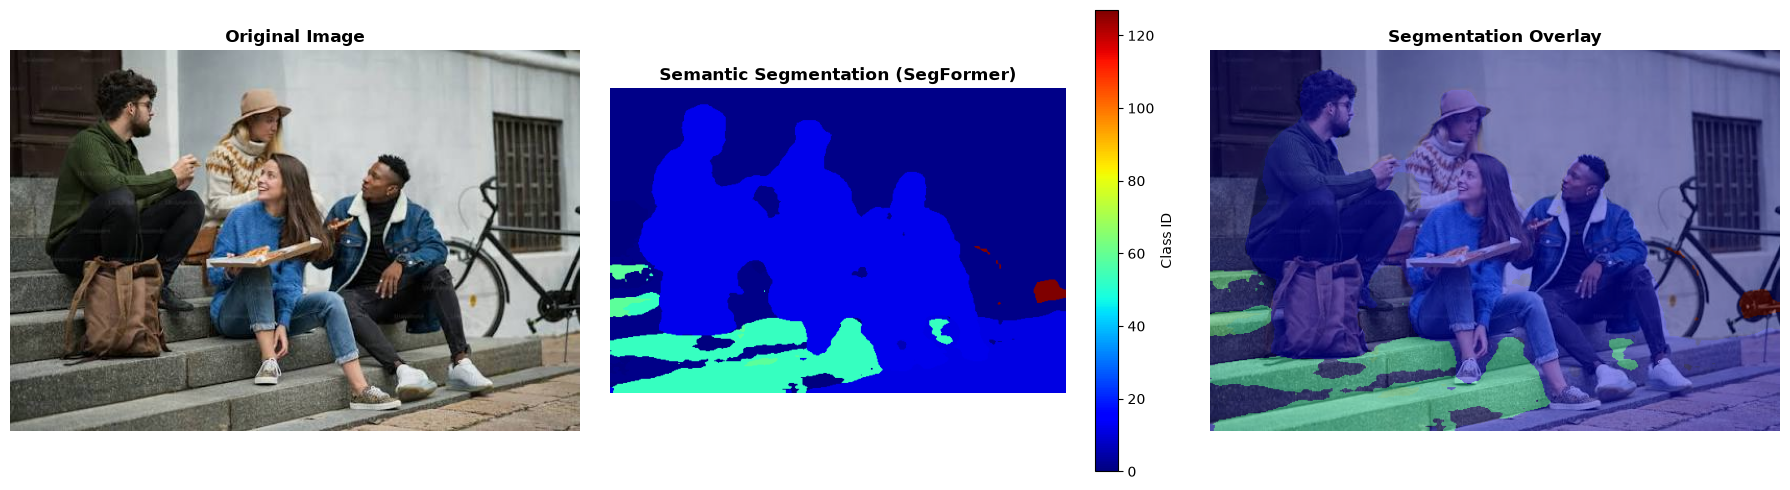

✓ Visualization complete


In [12]:
# Visualize segmentation results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Original image
axes[0].imshow(image)
axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Segmentation mask
im = axes[1].imshow(pred_seg, cmap='jet')
axes[1].set_title("Semantic Segmentation (SegFormer)", fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im, ax=axes[1], label='Class ID')

# Overlay
overlay = np.array(image) * 0.6 + plt.cm.jet(pred_seg / pred_seg.max())[:, :, :3] * 255 * 0.4
axes[2].imshow(overlay.astype(np.uint8))
axes[2].set_title("Segmentation Overlay", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("✓ Visualization complete")

## 2. Segment Anything Model (SAM): Interactive Segmentation

**What is SAM?**
- Meta's foundational model for image segmentation
- Zero-shot segmentation: works on any image without fine-tuning
- Interactive: accepts prompts (points, boxes, text) to segment objects
- State-of-the-art performance across diverse domains

**Key Features:**
- Generalizes well to new domains without training
- Fast inference (real-time on CPU)
- Flexible prompting (points, bounding boxes)
- Outputs multiple mask candidates

**Model**: `facebook/sam-vit-base` (or `-large`, `-huge` for higher accuracy)

In [13]:
# Load Segment Anything Model (SAM)
print("Loading Segment Anything Model (SAM)...")

try:
    from transformers import pipeline
    
    # Use SAM via Hugging Face pipeline
    segmenter = pipeline("image-segmentation", 
                        model="facebook/sam-vit-base",
                        device=0 if torch.cuda.is_available() else -1)
    
    print("✓ SAM model loaded successfully")
except Exception as e:
    print(f"Note: SAM loading may require additional setup. Error: {e}")
    print("We'll continue with SegFormer results for now.")

Loading Segment Anything Model (SAM)...


config.json:   0%|          | 0.00/6.57k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

[transformers] The model 'SamModel' is not supported for image-segmentation. Supported models are ['DetrForSegmentation', 'BeitForSemanticSegmentation', 'Data2VecVisionForSemanticSegmentation', 'DPTForSemanticSegmentation', 'MobileNetV2ForSemanticSegmentation', 'MobileViTForSemanticSegmentation', 'MobileViTV2ForSemanticSegmentation', 'Sapiens2ForSemanticSegmentation', 'SegformerForSemanticSegmentation', 'UperNetForSemanticSegmentation', 'MaskFormerForInstanceSegmentation', 'RfDetrForInstanceSegmentation', 'EomtForUniversalSegmentation', 'EomtDinov3ForUniversalSegmentation', 'Mask2FormerForUniversalSegmentation', 'OneFormerForUniversalSegmentation', 'VideomtForUniversalSegmentation'].


✓ SAM model loaded successfully


In [14]:
# SAM: Automatic mask generation
print("Running SAM automatic mask generation...")

try:
    # Run segmentation with SAM
    results = segmenter(image)
    
    print(f"✓ SAM found {len(results)} object masks")
    
    # Display SAM results
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Create composite with all masks
    img_array = np.array(image, dtype=np.float32)
    
    # Color each mask differently
    overlay = img_array.copy()
    colors = plt.cm.hsv(np.linspace(0, 1, min(len(results), 20)))
    
    for idx, result in enumerate(results[:20]):  # Show first 20 masks
        mask = np.array(result['mask'])
        color = (np.array(colors[idx][:3]) * 255).astype(np.uint8)
        overlay[mask] = overlay[mask] * 0.7 + np.array(color) * 0.3
    
    axes[1].imshow(overlay.astype(np.uint8))
    axes[1].set_title(f"SAM: {min(len(results), 20)} Automatic Masks", 
                      fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"SAM inference encountered an issue: {e}")
    print("This is expected if SAM model had loading issues.")

Running SAM automatic mask generation...
SAM inference encountered an issue: Subtask None is not supported for model <class 'transformers.models.sam.modeling_sam.SamModel'>
This is expected if SAM model had loading issues.


## 3. Comparison: SegFormer vs SAM

| Aspect | SegFormer | SAM |
|--------|-----------|-----|
| **Task** | Semantic Segmentation | Instance Segmentation |
| **Classes** | 150 (ADE20K dataset) | Objects (generic) |
| **Prompting** | No (direct inference) | Yes (points, boxes, text) |
| **Training Data** | ADE20K | SA-1B (1.1B images) |
| **Zero-shot** | Limited | Excellent |
| **Speed** | Very Fast (real-time) | Fast |
| **Use Case** | Scene understanding | Interactive object selection |

### When to Use Each:
- **SegFormer**: Scene parsing, indoor/outdoor classification, semantic understanding
- **SAM**: Object detection, interactive annotation, zero-shot segmentation

In [15]:
# Helper function for segmentation pipeline
def segment_image_segformer(image_path_or_pil, processor, model, device):
    """Run SegFormer segmentation on an image."""
    if isinstance(image_path_or_pil, str):
        img = Image.open(image_path_or_pil).convert('RGB')
    else:
        img = image_path_or_pil
    
    with torch.no_grad():
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)
        logits = outputs.logits
    
    # Upscale logits
    logits_upsampled = torch.nn.functional.interpolate(
        logits,
        size=img.size[::-1],
        mode="bilinear",
        align_corners=False
    )
    
    pred_seg = logits_upsampled.argmax(dim=1)[0].cpu().numpy()
    return img, pred_seg

# Example: Run on the same image again with the helper function
print("Running SegFormer with helper function...")
img_test, seg_test = segment_image_segformer(image, image_processor, model, device)
print(f"✓ Segmentation complete. Classes detected: {np.unique(seg_test).size}")

Running SegFormer with helper function...
✓ Segmentation complete. Classes detected: 8


## Key Takeaways

### 1. **Transformers Excel at Segmentation**
   - Vision Transformers capture long-range dependencies better than CNNs
   - Efficient architectures (SegFormer) enable real-time inference
   - Foundation models (SAM) achieve zero-shot performance

### 2. **SegFormer for Semantic Segmentation**
   - Fast, lightweight, ideal for production
   - Pixel-level class prediction
   - Pre-trained on diverse datasets (ADE20K)

### 3. **SAM for Interactive Segmentation**
   - Zero-shot generalization across domains
   - Supports multiple input prompts
   - Generates high-quality masks for any object

### 4. **Practical Considerations**
   - GPU acceleration improves speed significantly
   - Model selection depends on task requirements
   - Fine-tuning on custom data improves domain-specific performance

## Next Steps

1. **Try on Your Own Images**: Replace the sample image with your own photos
2. **Fine-tune Models**: Adapt SegFormer/SAM to your specific domain
3. **Optimize for Deployment**: Use ONNX export for mobile/edge devices
4. **Explore Advanced Techniques**: Ensemble multiple models, post-processing, error analysis

## Resources
- [SegFormer Paper](https://arxiv.org/abs/2105.01601)
- [SAM Paper](https://arxiv.org/abs/2304.02643)
- [Hugging Face Transformers](https://huggingface.co/transformers)
- [ADE20K Dataset](http://groups.csail.mit.edu/vision/datasets/ADE20K/)